# Siemens- Bussines Case Project 2025/2026
**DATA VISUALIZATION AND PREPROCESSING NOTEBOOK**

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

from statsmodels.tsa.holtwinters import ExponentialSmoothing

## 2. Data importation

In [2]:
data= pd.read_excel("Case2_market_data_share.xlsx", sheet_name="Sheet1")
time= pd.read_excel("Case2_market_data_share.xlsx", sheet_name="Sheet2")
training=pd.read_excel("Case2_data_extract_share_fixed.xlsx", sheet_name="training")
validation=pd.read_excel("Case2_data_extract_share_fixed.xlsx", sheet_name="validation")

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Trianing Exploration">    </a>
# Training Dataset
       
</div>


## 3. Data exploration and understanding

**METADATA:**


### 3.1. Data Overview

In [3]:
#overview the dataset
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Anon Period              4237 non-null   int64 
 1   TGL Biz Desc             4237 non-null   object
 2   TGL Business Unit        4237 non-null   object
 3   TGL Business Segment     4237 non-null   object
 4   TGL Business Subsegment  4237 non-null   object
 5   Orders cons. (anon)      4237 non-null   int64 
 6   Revenue cons. (anon)     4237 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 231.8+ KB


In [4]:
#first 20 rows
training.head(20)

,Anon Period,TGL Biz Desc,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon)
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277
1,2,SSI,SSI027,SSI02710,SSI02710,0,334
2,3,SSI,SSI027,SSI02710,SSI02710,0,334
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112
5,6,SSI,SSI027,SSI02710,SSI02710,0,38468
6,7,SSI,SSI027,SSI02710,SSI02710,0,334
7,8,SSI,SSI027,SSI02710,SSI02710,0,334
8,9,SSI,SSI027,SSI02710,SSI02710,0,-37173
9,10,SSI,SSI027,SSI02710,SSI02710,0,38094


In [5]:
#descriptive statistics for numerical data
training.describe().round(2)

,Anon Period,Orders cons. (anon),Revenue cons. (anon)
count,4237.00,4.237000e+03,4.237000e+03
mean,22.51,4.007662e+07,3.597641e+07
std,12.24,7.041486e+07,6.378604e+07
min,1.00,-5.610188e+07,-1.201076e+07
25%,12.00,8.713890e+05,1.020192e+06
50%,23.00,9.281978e+06,8.850535e+06
75%,33.00,4.331285e+07,3.646013e+07
max,42.00,5.950944e+08,4.200361e+08


### 3.2. Checking Duplicates

In [6]:
#checking number of duplicates
training.duplicated().sum()

np.int64(0)

### 3.3. Checking Missing Values

In [7]:
#checking number of missing values
training.isna().sum()

Anon Period                0
TGL Biz Desc               0
TGL Business Unit          0
TGL Business Segment       0
TGL Business Subsegment    0
Orders cons. (anon)        0
Revenue cons. (anon)       0
dtype: int64

In [8]:
training.nunique()

Anon Period                  42
TGL Biz Desc                  1
TGL Business Unit             4
TGL Business Segment         24
TGL Business Subsegment     134
Orders cons. (anon)        3943
Revenue cons. (anon)       3958
dtype: int64

We should drop "TGL Biz Desc"

In [9]:
training[(training["Orders cons. (anon)"] == 0) & (training["Revenue cons. (anon)"] == 0)]

,Anon Period,TGL Biz Desc,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon)
49,25,SSI,SSI027,SSI02710,SSI0271004,0,0
50,27,SSI,SSI027,SSI02710,SSI0271004,0,0
51,28,SSI,SSI027,SSI02710,SSI0271004,0,0
52,29,SSI,SSI027,SSI02710,SSI0271004,0,0
53,30,SSI,SSI027,SSI02710,SSI0271004,0,0
...,...,...,...,...,...,...,...
4083,40,SSI,SSI070,SSI07081,SSI0708199,0,0
4187,40,SSI,SSI070,SSI07082,SSI0708299,0,0
4230,23,SSI,SSI070,SSI07098,SSI07098,0,0
4231,24,SSI,SSI070,SSI07098,SSI07098,0,0


### 3.4 Checking Distribution

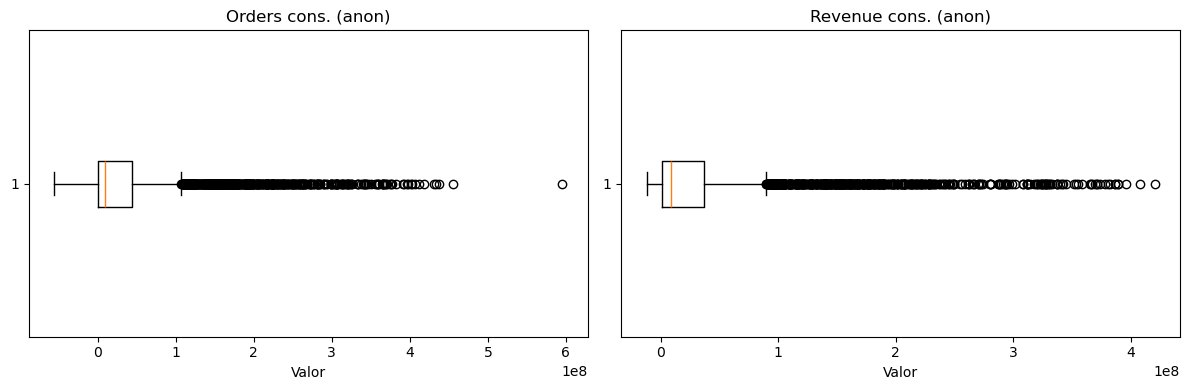

In [10]:
cols = ["Orders cons. (anon)", "Revenue cons. (anon)"]

x = training[cols].apply(pd.to_numeric, errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(cols):
    values = x[col].dropna()
    axes[i].boxplot(values, vert=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("Valor")

plt.tight_layout()
plt.show()

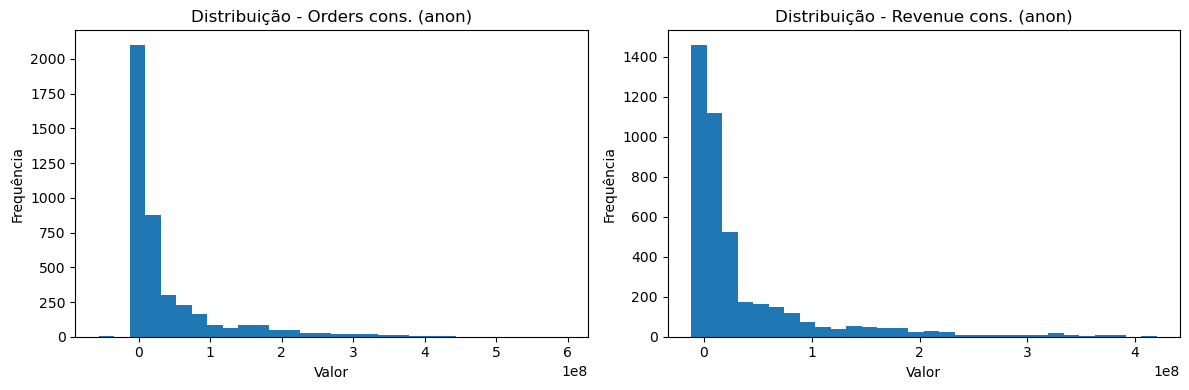

In [11]:
cols = ["Orders cons. (anon)", "Revenue cons. (anon)"]

# converter para numérico
x = training[cols].apply(pd.to_numeric, errors="coerce")

# histogramas separados
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(cols):
    values = x[col].dropna()
    axes[i].hist(values, bins=30)
    axes[i].set_title(f"Distribuição - {col}")
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

### 3.5. Checking Incoherencies

In [12]:
training[training["Orders cons. (anon)"] < 0]

,Anon Period,TGL Biz Desc,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon)
35,36,SSI,SSI027,SSI02710,SSI02710,-4008,0
95,10,SSI,SSI027,SSI02780,SSI02780,-208,-208
271,32,SSI,SSI027,SSI02782,SSI02782,-92992,-24882
444,31,SSI,SSI027,SSI02782,SSI0278214,-3785,7993
453,40,SSI,SSI027,SSI02782,SSI0278214,-99973,92345
...,...,...,...,...,...,...,...
4064,32,SSI,SSI070,SSI07081,SSI0708170,-12062,-44170
4067,35,SSI,SSI070,SSI07081,SSI0708170,-13065,45939
4070,38,SSI,SSI070,SSI07081,SSI0708170,-186224,176949
4119,35,SSI,SSI070,SSI07082,SSI0708210,-2877775,14130325


In [13]:
training[training["Revenue cons. (anon)"] < 0]

,Anon Period,TGL Biz Desc,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon)
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277
8,9,SSI,SSI027,SSI02710,SSI02710,0,-37173
95,10,SSI,SSI027,SSI02780,SSI02780,-208,-208
244,5,SSI,SSI027,SSI02782,SSI02782,161740,-8227861
245,6,SSI,SSI027,SSI02782,SSI02782,157859,-2808615
247,8,SSI,SSI027,SSI02782,SSI02782,164094,-646583
251,12,SSI,SSI027,SSI02782,SSI02782,3511916,-899699
265,26,SSI,SSI027,SSI02782,SSI02782,1348828,-21164
271,32,SSI,SSI027,SSI02782,SSI02782,-92992,-24882
279,40,SSI,SSI027,SSI02782,SSI02782,0,-7


### Cheking the Hierarcie

In [14]:
training.groupby("TGL Business Segment")["TGL Business Unit"].nunique().value_counts()

TGL Business Unit
1    24
Name: count, dtype: int64

In [15]:
training["TGL Business Segment"].unique().tolist()

['SSI02710',
 'SSI02780',
 'SSI02782',
 'SSI02784',
 'SSI02786',
 'SSI02792',
 'SSI02793',
 'SSI02796',
 'SSI02798',
 'SSI02799',
 'SSI03781',
 'SSI03782',
 'SSI03784',
 'SSI03798',
 'SSI03799',
 'SSI04781',
 'SSI04783',
 'SSI04784',
 'SSI04799',
 'SSI07081',
 'SSI07082',
 'SSI07083',
 'SSI07098',
 'SSI07099']

In [16]:
training.groupby("TGL Business Unit")["TGL Biz Desc"].nunique().value_counts()

TGL Biz Desc
1    4
Name: count, dtype: int64

In [17]:
training["TGL Business Unit"].unique().tolist()

['SSI027', 'SSI037', 'SSI047', 'SSI070']

## 4. Data Preparation

### 4.1. Data preparation

Não sei se deviamos dropar esta ou TGL Biz Desc, por causa das hierarquias	

In [ ]:
training = training.drop(columns=["TGL Biz Desc"])

### 4.2. Feature Engineering


In [20]:
time_unique = time[["Period", "DATE"]].drop_duplicates(subset="Period")
map_period_date = dict(zip(time_unique["Period"], time_unique["DATE"]))
training["Date"] = training["Anon Period"].map(map_period_date)

# mover a coluna "Date" para a primeira posição
col = training.pop("Date")
training.insert(1, "Date", col)
training.head()

,Anon Period,Date,TGL Biz Desc,TGL Business Unit,TGL Business Segment,Orders cons. (anon),Revenue cons. (anon)
0,1,2021-04-01,SSI,SSI027,SSI02710,0,-390277
1,2,2021-05-01,SSI,SSI027,SSI02710,0,334
2,3,2021-06-01,SSI,SSI027,SSI02710,0,334
3,4,2021-07-01,SSI,SSI027,SSI02710,0,1811758
4,5,2021-08-01,SSI,SSI027,SSI02710,0,80112


<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# Data Dataset
       
</div>


**METADATA:**


### 3.1. Data Overview

In [22]:
#overview the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 78 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    180 non-null    int64  
 1   China_Core_Inflation_Rate                 178 non-null    float64
 2   China_Exports                             178 non-null    float64
 3   China_GDP                                 15 non-null     float64
 4   China_GDP_from_Construction               60 non-null     float64
 5   China_GDP_from_Manufacturing              60 non-null     float64
 6   China_Industrial_Production               176 non-null    float64
 7   China_Industrial_Production_Mom           170 non-null    float64
 8   China_Inflation_Rate                      178 non-null    float64
 9   China_Interest_Rate                       137 non-null    float64
 10  China_Steel_Production                

In [23]:
#first 20 rows
data.head(20)

,Period,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
0,-131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6955.00
1,-130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7264.00
2,-129,1.0,137.35,NaN,10710.5,76425.9,13.70,NaN,2.9,NaN,...,0.9,153.326,NaN,554.4,1925.9,8.5,0.2,1.1,NaN,7090.00
3,-128,1.1,145.45,NaN,NaN,NaN,13.40,NaN,3.3,NaN,...,0.9,156.763,NaN,NaN,NaN,7.7,0.4,1.2,0.25,6764.00
4,-127,1.1,139.26,NaN,NaN,NaN,13.90,NaN,3.5,NaN,...,0.9,157.769,NaN,NaN,NaN,6.9,0.4,1.1,0.25,6619.00
5,-126,1.1,144.99,NaN,18012.5,118221.6,13.30,NaN,3.6,NaN,...,0.8,158.624,NaN,549.2,1947.4,6.3,0.3,1.1,0.25,6605.00
6,-125,1.3,135.96,NaN,NaN,NaN,13.10,NaN,4.4,NaN,...,0.6,164.234,NaN,NaN,NaN,5.7,-0.3,1.2,0.25,6543.00
7,-124,1.5,153.29,NaN,NaN,NaN,13.30,NaN,5.1,NaN,...,0.8,165.621,NaN,NaN,NaN,5.4,0.1,1.1,0.25,6418.00
8,-123,1.7,154.14,6192.56,27259.3,165123.1,13.50,NaN,4.6,NaN,...,0.8,168.510,15048.97,545.1,1957.6,6.1,1.0,1.5,0.25,6648.00
9,-122,2.3,150.70,NaN,NaN,NaN,13.41,NaN,4.9,NaN,...,1.0,169.897,NaN,NaN,NaN,4.7,-0.2,1.6,0.25,7191.38


In [24]:
#descriptive statistics for numerical data
data.describe().round(2)

,Period,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
count,180.00,178.00,178.00,15.00,60.00,60.00,176.00,170.00,178.00,137.00,...,178.00,178.00,15.00,60.00,60.00,178.00,178.00,178.00,175.00,180.00
mean,-41.50,1.37,215.89,13031.13,33122.37,173068.40,7.42,0.65,2.08,4.21,...,2.59,209.07,20549.85,719.75,2129.46,1.03,0.07,2.60,1.43,6908.79
std,52.11,0.60,56.05,4130.32,22602.81,96035.07,5.04,3.29,1.49,0.69,...,1.40,31.90,4404.15,143.70,148.43,3.86,1.33,1.98,1.75,529.05
min,-131.00,-0.30,80.38,6192.56,4749.00,42670.30,-13.50,-22.10,-0.80,3.10,...,0.60,147.14,15048.97,533.20,1906.30,-17.20,-13.20,-0.20,0.25,4746.00
25%,-86.25,0.90,177.79,10208.83,13793.25,93960.05,5.40,0.44,1.30,3.70,...,1.70,188.11,17244.41,572.33,2000.15,-0.98,-0.28,1.42,0.25,6648.25
50%,-41.50,1.50,204.65,12537.56,28693.25,163199.35,6.30,0.55,2.00,4.30,...,2.10,198.92,19612.10,654.10,2104.35,1.60,0.10,2.10,0.25,6955.50
75%,3.25,1.80,263.34,16599.06,47756.28,227774.98,9.05,0.76,2.70,4.31,...,3.18,215.55,22610.57,867.68,2251.68,3.18,0.50,3.08,2.00,7270.16
max,48.00,2.50,339.66,18743.80,88862.80,404518.50,35.10,36.56,6.50,5.77,...,6.60,283.27,29184.89,904.40,2389.00,16.10,6.60,9.10,5.50,7960.90


### 3.2. Checking Duplicates

In [25]:
#checking number of duplicates
data.duplicated().sum()

np.int64(0)

### 3.3. Checking Missing Values

In [26]:
#checking number of missing values
data.isna().sum()

Period                                       0
China_Core_Inflation_Rate                    2
China_Exports                                2
China_GDP                                  165
China_GDP_from_Construction                120
                                          ... 
United_States_Industrial_Production          2
United_States_Industrial_Production_Mom      2
United_States_Inflation_Rate                 2
United_States_Interest_Rate                  5
United_States_Steel_Production               0
Length: 78, dtype: int64

In [27]:
data.nunique()

Period                                     180
China_Core_Inflation_Rate                   28
China_Exports                              176
China_GDP                                   15
China_GDP_from_Construction                 60
                                          ... 
United_States_Industrial_Production         88
United_States_Industrial_Production_Mom     34
United_States_Inflation_Rate                62
United_States_Interest_Rate                 17
United_States_Steel_Production             142
Length: 78, dtype: int64

In [28]:
data.nunique()[data.nunique() == 1]

Series([], dtype: int64)

### 3.5. Checking Distribution

In [29]:
# selecionar só colunas numéricas
data_num = data.select_dtypes(include="number")

# matriz de correlação de Spearman
corr_spearman = data_num.corr(method="spearman")

# ficar só com a metade de cima da matriz
upper = corr_spearman.where(np.triu(np.ones(corr_spearman.shape), k=1).astype(bool))

# transformar em lista de pares
corr_high_abs = (
    upper.stack()
    .reset_index()
)

corr_high_abs.columns = ["Variavel_1", "Variavel_2", "Correlacao"]

# filtrar correlações fortes
corr_high_abs = corr_high_abs[abs(corr_high_abs["Correlacao"]) > 0.8]

# ordenar
corr_high_abs = corr_high_abs.sort_values(by="Correlacao", ascending=False)

print(corr_high_abs)

                       Variavel_1                    Variavel_2  Correlacao
1311         France_Interest_Rate           Italy_Interest_Rate    1.000000
1301         France_Interest_Rate         Germany_Interest_Rate    1.000000
1836        Germany_Interest_Rate           Italy_Interest_Rate    1.000000
302   China_GDP_from_Construction  China_GDP_from_Manufacturing    0.996999
229                     China_GDP  China_GDP_from_Manufacturing    0.996429
...                           ...                           ...         ...
49                         Period        Japan_Steel_Production   -0.844283
485   China_Industrial_Production  Japan_GDP_from_Manufacturing   -0.852547
8                          Period           China_Interest_Rate   -0.938571
717           China_Interest_Rate             United_States_GDP   -0.943685
233                     China_GDP           China_Interest_Rate   -0.943685

[198 rows x 3 columns]


### 3.7. Checking Incoherencies

## 4. Data Preparation

### 4.1. Data preparation

In [30]:
# só numéricas
data_num = data.select_dtypes(include="number")

# correlação
corr = data_num.corr(method="spearman").abs()

# metade superior
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# colunas a remover
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

print(to_drop)

data = data_num.drop(columns=to_drop)
data.head()

['China_Exports', 'China_GDP', 'China_GDP_from_Construction', 'China_GDP_from_Manufacturing', 'China_Interest_Rate', 'China_Steel_Production', 'France_Exports', 'France_GDP_from_Manufacturing', 'France_Inflation_Rate', 'Germany_Exports', 'Germany_GDP', 'Germany_GDP_from_Manufacturing', 'Germany_Inflation_Rate', 'Germany_Interest_Rate', 'Italy_Exports', 'Italy_GDP', 'Italy_GDP_from_Manufacturing', 'Italy_Inflation_Rate', 'Italy_Interest_Rate', 'Japan_Exports', 'Japan_GDP', 'Japan_GDP_from_Construction', 'Japan_GDP_from_Manufacturing', 'Japan_Inflation_Rate', 'Japan_Steel_Production', 'Switzerland_Core_Inflation_Rate', 'Switzerland_Exports', 'Switzerland_GDP', 'Switzerland_Inflation_Rate', 'Switzerland_Interest_Rate', 'United_Kingdom_Core_Inflation_Rate', 'United_Kingdom_Exports', 'United_Kingdom_GDP', 'United_Kingdom_GDP_from_Construction', 'United_Kingdom_GDP_from_Manufacturing', 'United_Kingdom_Inflation_Rate', 'United_States_Exports', 'United_States_GDP', 'United_States_GDP_from_Cons

,Period,China_Core_Inflation_Rate,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,France_Core_Inflation_Rate,France_GDP,France_GDP_from_Construction,France_Industrial_Production,France_Industrial_Production_Mom,...,Switzerland_Industrial_Production,Switzerland_Industrial_Production_Mom,United_Kingdom_Industrial_Production,United_Kingdom_Industrial_Production_Mom,United_Kingdom_Interest_Rate,United_Kingdom_Steel_Production,United_States_Core_Inflation_Rate,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Steel_Production
0,-131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,899.0,NaN,NaN,NaN,6955.0
1,-130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,894.0,NaN,NaN,NaN,7264.0
2,-129,1.0,13.7,NaN,2.9,1.4,NaN,32841.0,4.2,-0.4,...,7.9,-0.2,-2.8,-1.4,NaN,793.0,0.9,8.5,0.2,7090.0
3,-128,1.1,13.4,NaN,3.3,0.8,NaN,NaN,5.3,0.7,...,NaN,NaN,-4.6,-0.9,0.5,780.0,0.9,7.7,0.4,6764.0
4,-127,1.1,13.9,NaN,3.5,0.6,NaN,NaN,2.4,-1.2,...,NaN,NaN,-2.8,-0.1,0.5,789.0,0.9,6.9,0.4,6619.0


Forward fill for the values that have low frequency

In [31]:
ffill_cols = ["France_GDP", "France_GDP_from_Construction","Germany_GDP_from_Construction", "Italy_GDP_from_Construction",
              'Switzerland_Industrial_Production','Switzerland_Industrial_Production_Mom']

# forward fill
data[ffill_cols] = data[ffill_cols].ffill()

Linear Interpolation for filling a few missing values

In [32]:
interp_cols = ["China_Core_Inflation_Rate", "China_Industrial_Production",'China_Industrial_Production_Mom','China_Inflation_Rate',
    "France_Core_Inflation_Rate","France_Industrial_Production",'France_Industrial_Production_Mom','France_Interest_Rate',
    "Germany_Core_Inflation_Rate","Germany_Industrial_Production",'Germany_Industrial_Production_Mom',
    "Italy_Core_Inflation_Rate","Italy_Industrial_Production",'Italy_Industrial_Production_Mom',
    "Japan_Core_Inflation_Rate","Japan_Industrial_Production",'Japan_Industrial_Production_Mom','Japan_Interest_Rate',
    "United_Kingdom_Industrial_Production",'United_Kingdom_Industrial_Production_Mom','United_Kingdom_Interest_Rate',
    "United_States_Core_Inflation_Rate","United_States_Industrial_Production",'United_States_Industrial_Production_Mom']

# interpolação linear
data[interp_cols] = data[interp_cols].interpolate(method="linear")

In [33]:
# colunas a remover
to_drop = ['France_Steel_Production','Italy_Steel_Production','United_Kingdom_Steel_Production']

data = data.drop(columns=to_drop)

### 4.2. Feature Engineering

In [34]:
time_unique = time[["Period", "DATE"]].drop_duplicates(subset="Period")
map_period_date = dict(zip(time_unique["Period"], time_unique["DATE"]))
data["Date"] = data["Period"].map(map_period_date)

# mover a coluna "Date" para a primeira posição
col = data.pop("Date")
data.insert(1, "Date", col)

data.head()

,Period,Date,China_Core_Inflation_Rate,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,France_Core_Inflation_Rate,France_GDP,France_GDP_from_Construction,France_Industrial_Production,...,Japan_Interest_Rate,Switzerland_Industrial_Production,Switzerland_Industrial_Production_Mom,United_Kingdom_Industrial_Production,United_Kingdom_Industrial_Production_Mom,United_Kingdom_Interest_Rate,United_States_Core_Inflation_Rate,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Steel_Production
0,-131,2010-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6955.0
1,-130,2010-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7264.0
2,-129,2010-06-01,1.0,13.7,NaN,2.9,1.4,NaN,32841.0,4.2,...,NaN,7.9,-0.2,-2.8,-1.4,NaN,0.9,8.5,0.2,7090.0
3,-128,2010-07-01,1.1,13.4,NaN,3.3,0.8,NaN,32841.0,5.3,...,0.1,7.9,-0.2,-4.6,-0.9,0.5,0.9,7.7,0.4,6764.0
4,-127,2010-08-01,1.1,13.9,NaN,3.5,0.6,NaN,32841.0,2.4,...,0.1,7.9,-0.2,-2.8,-0.1,0.5,0.9,6.9,0.4,6619.0


## 5. Merge

In [51]:
# merge
df= segment_full.merge(
    data,
    left_on="Anon Period",
    right_on="Period",
    how="left"
)

# opcional: apagar Period duplicado
df = df.drop(columns=["Period"])

print(df.shape)
print(df.head())

(1008, 40)
   Anon Period     Date_x TGL Biz Desc TGL Business Unit TGL Business Segment  \
0            1 2021-04-01          SSI            SSI027             SSI02710   
1            2 2021-05-01          SSI            SSI027             SSI02710   
2            3 2021-06-01          SSI            SSI027             SSI02710   
3            4 2021-07-01          SSI            SSI027             SSI02710   
4            5 2021-08-01          SSI            SSI027             SSI02710   

   Orders cons. (anon)  Revenue cons. (anon)     Date_y  \
0                  0.0             -390277.0 2021-04-01   
1                  0.0                 334.0 2021-05-01   
2                  0.0                 334.0 2021-06-01   
3                  0.0             1811758.0 2021-07-01   
4                  0.0               80112.0 2021-08-01   

   China_Core_Inflation_Rate  China_Industrial_Production  ...  \
0                        0.7                          9.8  ...   
1              

## 6. MODELS

### 6.1.Train_Test_Split

In [ ]:
nao correr split

In [ ]:
df = df.sort_values(["TGL Business Segment", "Anon Period"]).reset_index(drop=True)

initial_train = 24
test_size = 6
max_period = int(df["Anon Period"].max())

splits = []

train_end = initial_train

while train_end + test_size <= max_period:
    test_start = train_end + 1
    test_end = train_end + test_size

    train_idx = df["Anon Period"] <= train_end
    test_idx = (df["Anon Period"] >= test_start) & (df["Anon Period"] <= test_end)

    train_df = df[train_idx].copy()
    test_df = df[test_idx].copy()

    splits.append((train_df, test_df))

    print(f"Train: 1-{train_end} | Test: {test_start}-{test_end}")
    
    train_end += test_size

### 6.2.Feature Selection

### Filtered method

### Spearman

In [ ]:
# juntar X e y
train_fs = pd.concat([X_train, y_train], axis=1)

# só numéricas
train_fs_num = train_fs.select_dtypes(include="number")

# correlação com a target
corr_target = train_fs_num.corr(method="spearman")[target].drop(target)

# escolher features com correlação absoluta > 0.2
selected_filter = corr_target[abs(corr_target) > 0.2].index.tolist()

print("Filter selected:", selected_filter)

### WRAPPER METHOD

### RFE

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

# imputar missing
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# modelo base
xgb_base = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

# RFE
rfe = RFE(estimator=xgb_base, n_features_to_select=15)
rfe.fit(X_train_imp, y_train)

selected_wrapper = X_train.columns[rfe.support_].tolist()

print("Wrapper selected:", selected_wrapper)

### EMBEDDED METHOD

### XGBoost

In [58]:
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
import pandas as pd

imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train_imp, y_train)

feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

selected_embedded = feat_importance.head(15).index.tolist()

print("Embedded selected:", selected_embedded)

NameError: name 'X_train' is not defined

### 6.3.Exponential Smoothing

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


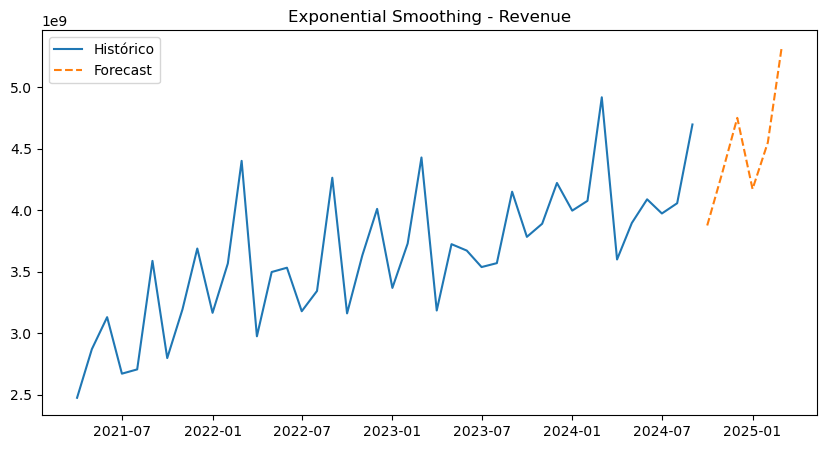

In [52]:
# preparar série

df= training.copy()
df["Date"] = pd.to_datetime(df["Date"])
ts = df.groupby("Date")["Revenue cons. (anon)"].sum().sort_index()

# modelo
model = ExponentialSmoothing(
    ts,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit = model.fit()

# previsão
forecast = fit.forecast(6)

# gráfico
plt.figure(figsize=(10, 5))
plt.plot(ts, label="Histórico")
plt.plot(forecast, label="Forecast", linestyle="--")
plt.title("Exponential Smoothing - Revenue")
plt.legend()
plt.show()

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


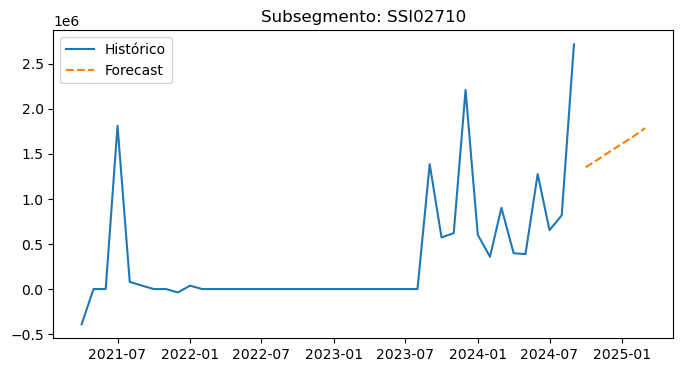

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


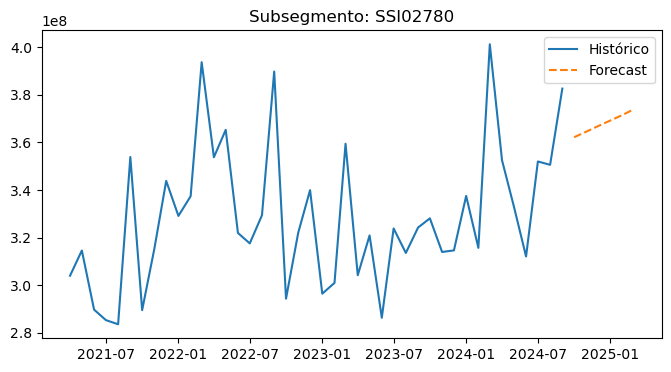

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


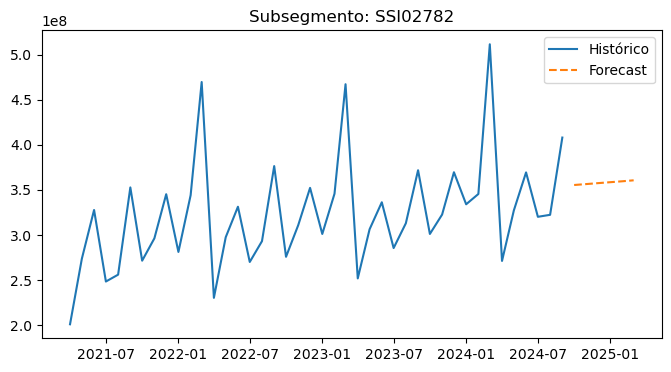

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


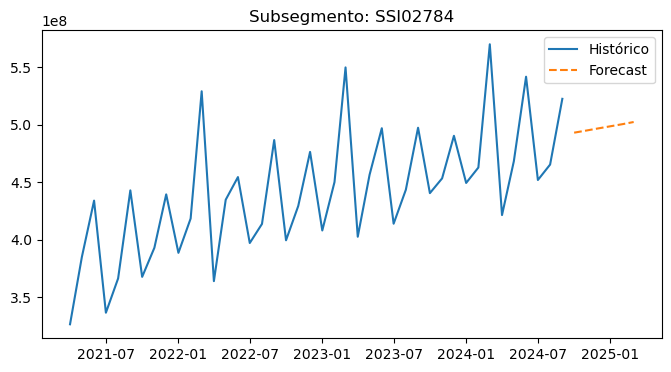

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


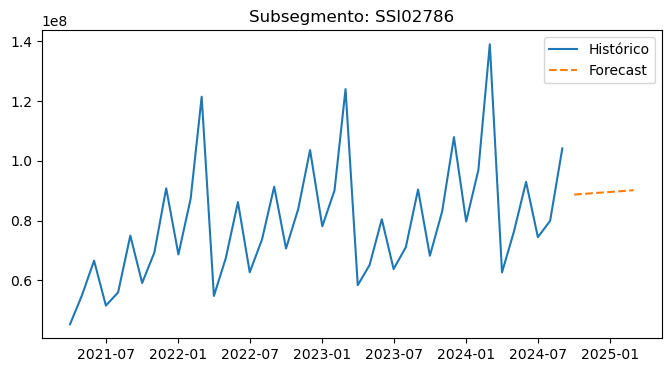

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


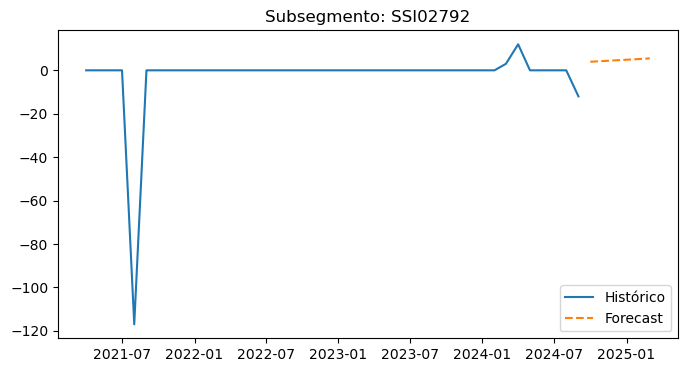

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


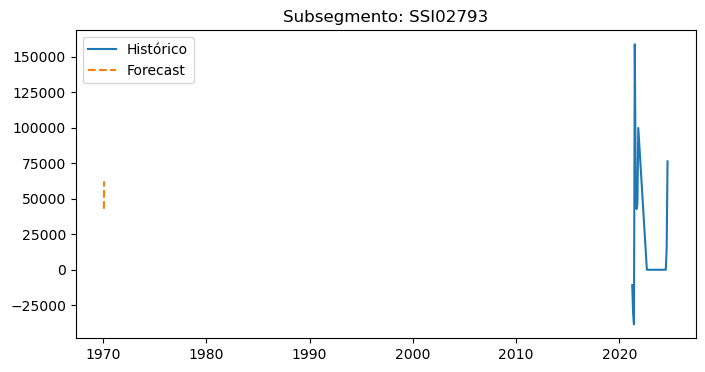

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


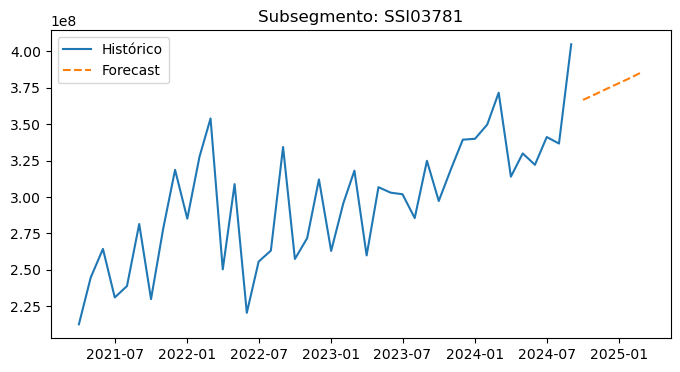

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


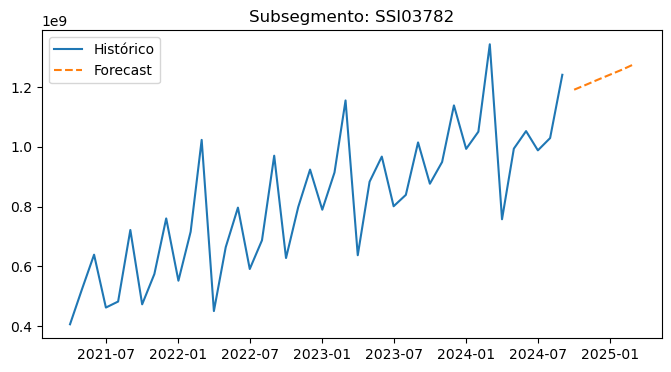

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


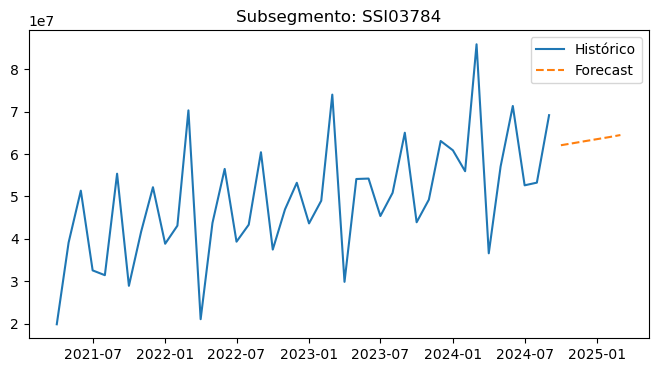

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


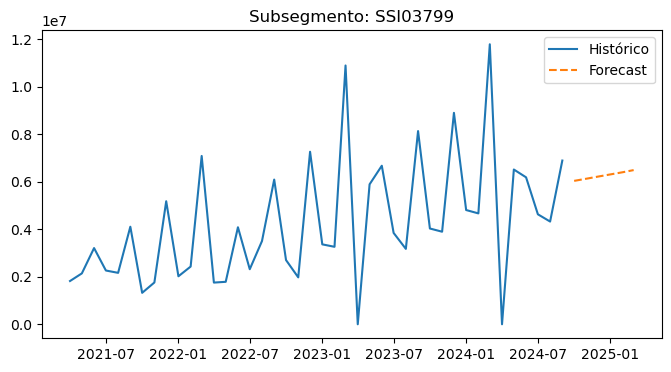

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


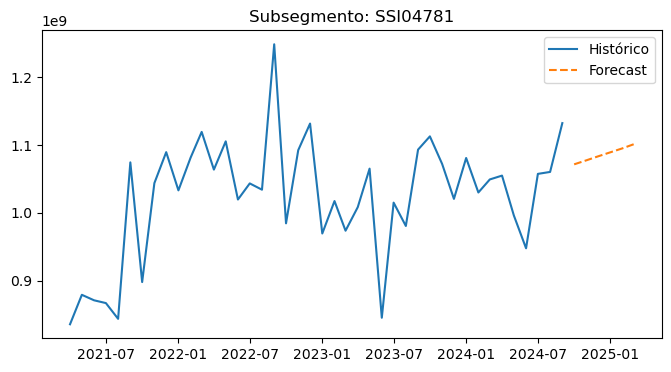

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


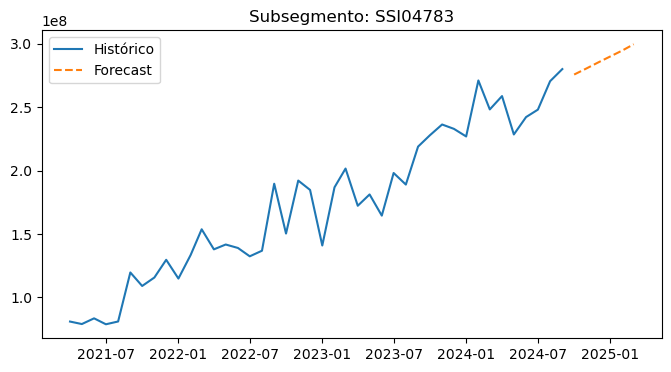

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


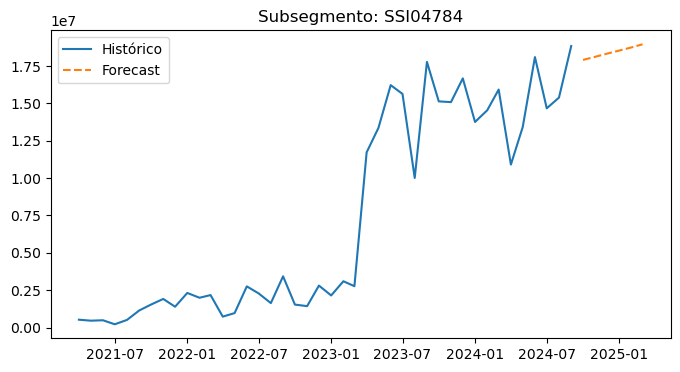

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


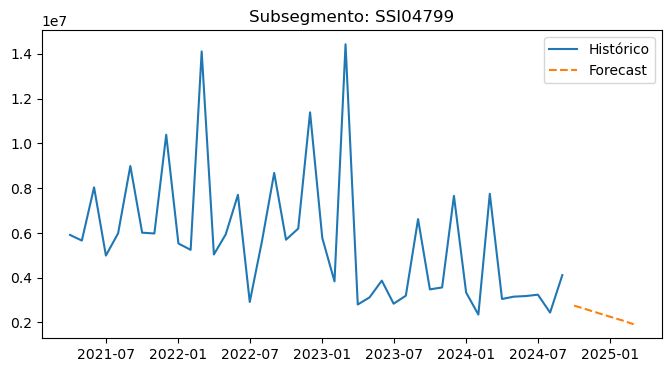

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


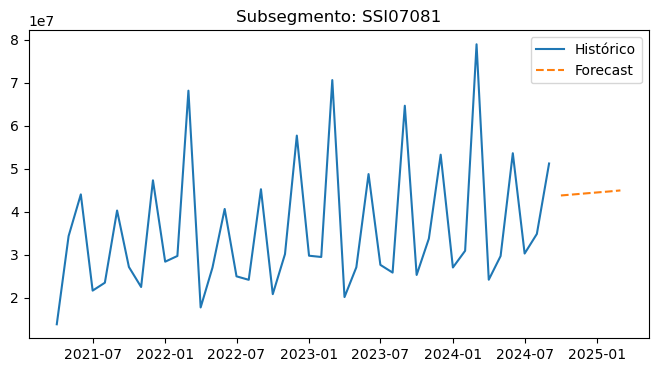

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


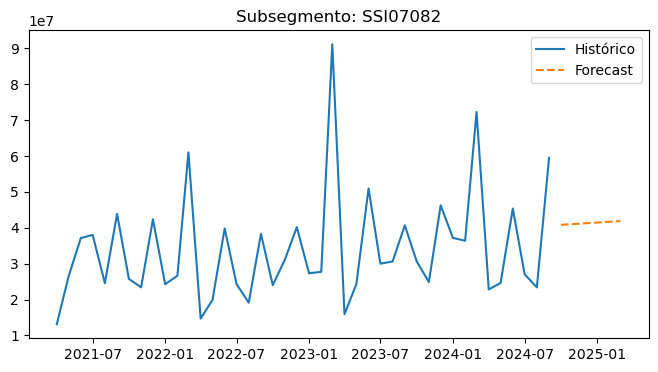

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


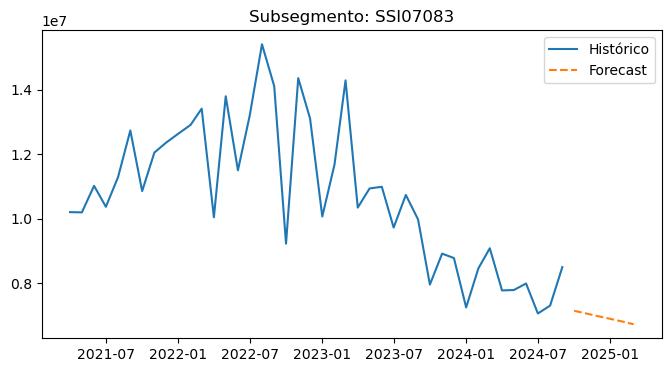

In [53]:
subs_escolhidos = ['SSI02710','SSI02780', 'SSI02782', 'SSI02784', 'SSI02786', 'SSI02792','SSI02793', 'SSI02796', 'SSI02798', 'SSI02799', 'SSI03781', 'SSI03782', 'SSI03784', 'SSI03798', 'SSI03799', 'SSI04781', 'SSI04783', 'SSI04784', 'SSI04799', 'SSI07081', 'SSI07082', 'SSI07083', 'SSI07098', 'SSI07099']

for sub in subs_escolhidos:
    df_sub = training[training["TGL Business Segment"] == sub].copy()
    ts = df_sub.groupby("Date")["Revenue cons. (anon)"].sum().sort_index()

    if len(ts) < 25:
        continue

    model = ExponentialSmoothing(ts, trend="add", seasonal=None)
    fit = model.fit()
    forecast = fit.forecast(6)

    plt.figure(figsize=(8,4))
    plt.plot(ts, label="Histórico")
    plt.plot(forecast, label="Forecast", linestyle="--")
    plt.title(f"Subsegmento: {sub}")
    plt.legend()
    plt.show()

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


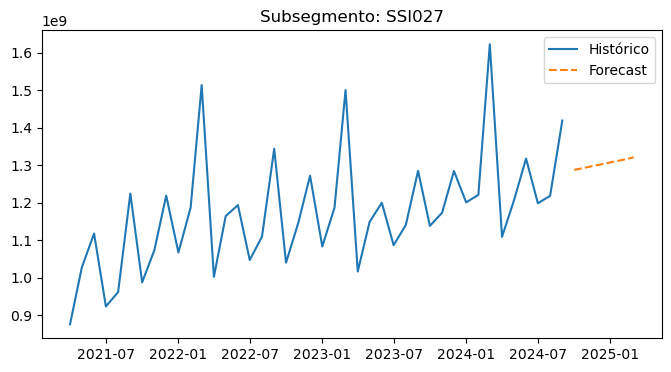

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


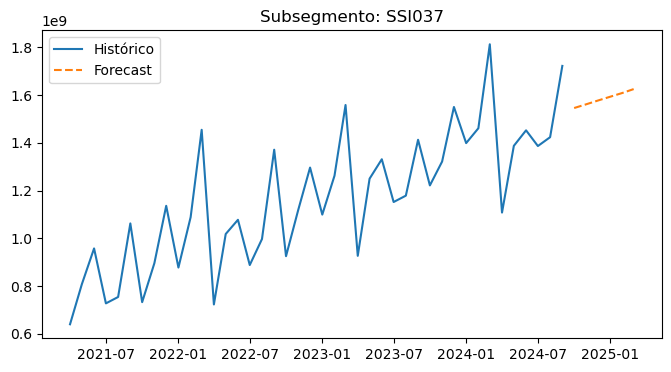

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


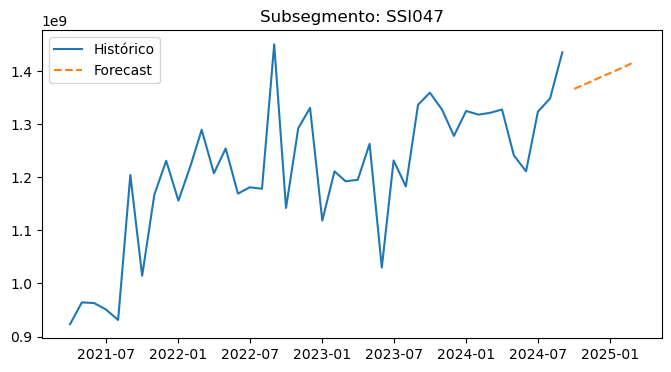

c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\alano\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


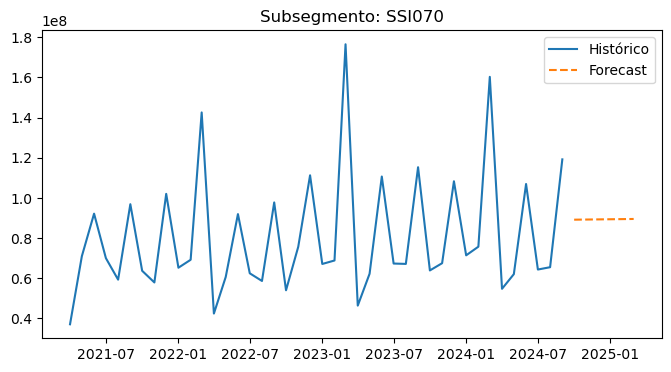

In [54]:
subs_escolhidos = ['SSI027', 'SSI037', 'SSI047', 'SSI070']

for sub in subs_escolhidos:
    df_sub = training[training["TGL Business Unit"] == sub].copy()
    ts = df_sub.groupby("Date")["Revenue cons. (anon)"].sum().sort_index()

    if len(ts) < 25:
        continue

    model = ExponentialSmoothing(ts, trend="add", seasonal=None)
    fit = model.fit()
    forecast = fit.forecast(6)

    plt.figure(figsize=(8,4))
    plt.plot(ts, label="Histórico")
    plt.plot(forecast, label="Forecast", linestyle="--")
    plt.title(f"Subsegmento: {sub}")
    plt.legend()
    plt.show()

### 6.4 XGBoost

In [55]:
# --- assumir que este já é o dataset com training + macros ---
df_xgb = df.copy()

# colunas principais
target = "Revenue cons. (anon)"
group_col = "TGL Business Segment"

# datas
df_xgb["Date"] = pd.to_datetime(df_xgb["Date"])

# ordenar
df_xgb = df_xgb.sort_values([group_col, "Date"]).reset_index(drop=True)

# -------------------------
# 1) FEATURES DE CALENDÁRIO
# -------------------------
df_xgb["month"] = df_xgb["Date"].dt.month
df_xgb["quarter"] = df_xgb["Date"].dt.quarter
df_xgb["year"] = df_xgb["Date"].dt.year

# -------------------------
# 2) LAGS DA TARGET
# -------------------------
for lag in [1, 2, 3, 6, 12]:
    df_xgb[f"lag_{lag}"] = df_xgb.groupby(group_col)[target].shift(lag)

# -------------------------
# 3) ROLLING FEATURES
# -------------------------
for window in [3, 6]:
    df_xgb[f"rolling_mean_{window}"] = (
        df_xgb.groupby(group_col)[target]
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )
    
    df_xgb[f"rolling_std_{window}"] = (
        df_xgb.groupby(group_col)[target]
        .transform(lambda x: x.shift(1).rolling(window).std())
    )

# -------------------------
# 4) DUMMIES DA HIERARQUIA
# -------------------------
cat_cols = [
    "TGL Biz Desc",
    "TGL Business Unit",
    "TGL Business Segment",
]

df_xgb = pd.get_dummies(df_xgb, columns=cat_cols, drop_first=False)

# -------------------------
# 5) REMOVER COLUNAS QUE NÃO VAIS USAR DIRETAMENTE
# -------------------------
drop_cols = ["Date"]   # podes acrescentar outras se quiseres
X = df_xgb.drop(columns=drop_cols + [target])
y = df_xgb[target]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (4237, 43)
Shape y: (4237,)


In [56]:
dataset_model = pd.concat([X, y], axis=1).dropna(subset=["lag_1", "lag_2", "lag_3", "lag_6", "lag_12"])

## Submission

In [57]:
#exporting submissiondataset 
submission = pd.DataFrame(X)
submission.to_csv("data_alano.csv", index=False)